In [17]:
import os
import sys
import gc
import glob
import math
import h5py
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_auc_score, roc_curve

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
print("PyTorch:", torch.__version__)

Device: cuda
PyTorch: 2.9.0+cu126


In [18]:
# Detect environment
if os.path.isdir('/kaggle/input'):
    ENV = 'kaggle'
elif os.path.isdir('/content'):
    ENV = 'colab'
else:
    ENV = 'local'

print(f"Environment: {ENV}")

if ENV == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

# Locate dataset
if ENV == 'kaggle':
    kaggle_root = '/kaggle/input/quark-gluon-jets'
    if os.path.isdir(kaggle_root):
        matches = glob.glob(os.path.join(kaggle_root, '**', '*.hdf5'), recursive=True)
    else:
        matches = glob.glob('/kaggle/input/**/*.hdf5', recursive=True)
    if not matches:
        raise FileNotFoundError('No .hdf5 found under /kaggle/input. Add the dataset first.')
    file_path = matches[0]
elif ENV == 'colab':
    file_path = '/content/drive/MyDrive/quark-gluon_data-set_n139306 (1).hdf5'
else:
    file_path = 'C:/Users/anjal/Downloads/Genie-Task/data/quark-gluon_data-set_n139306 (1).hdf5'

print('Dataset:', file_path)
with h5py.File(file_path, 'r') as f:
    print('X_jets shape:', f['X_jets'].shape)
    print('y shape:     ', f['y'].shape)

Environment: kaggle
Dataset: /kaggle/input/datasets/anjaliii25/quark-gluon-jets/quark-gluon_data-set_n139306 (1).hdf5
X_jets shape: (139306, 125, 125, 3)
y shape:      (139306,)


In [19]:
# Hyperparameters
MAX_NODES = 128
K_NEIGHBORS = 16
NODE_FEATURES = 7   # x, y, ecal, hcal, tracks, total_energy, log_energy
N_GLOBAL = 7        # jet-level physics features
BATCH_SIZE = 128
NUM_EPOCHS = 60
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-3
LABEL_SMOOTHING = 0.05
NODE_DROP_RATE = 0.05    # lighter node dropout
FEAT_NOISE_STD = 0.01   # lighter feature noise

print(f"MAX_NODES={MAX_NODES}, K={K_NEIGHBORS}, NODE_FEATURES={NODE_FEATURES}, N_GLOBAL={N_GLOBAL}")
print(f"BATCH_SIZE={BATCH_SIZE}, EPOCHS={NUM_EPOCHS}, LR={LEARNING_RATE}, WD={WEIGHT_DECAY}")
print(f"NODE_DROP={NODE_DROP_RATE}, FEAT_NOISE={FEAT_NOISE_STD}")

MAX_NODES=128, K=16, NODE_FEATURES=7, N_GLOBAL=7
BATCH_SIZE=128, EPOCHS=60, LR=0.0005, WD=0.001
NODE_DROP=0.05, FEAT_NOISE=0.01


In [20]:
# Image to point cloud conversion (with global jet features)

def image_to_pointcloud(image, max_nodes=MAX_NODES):
    """Convert jet image (125x125x3) to fixed-size point cloud (max_nodes, 7) + 7 global features."""
    mask = np.any(image > 0, axis=-1)
    coords = np.argwhere(mask)

    if len(coords) == 0:
        return np.zeros((max_nodes, NODE_FEATURES), dtype=np.float32), np.zeros(N_GLOBAL, dtype=np.float32)

    x = coords[:, 0].astype(np.float32) / 124.0
    y = coords[:, 1].astype(np.float32) / 124.0
    ecal   = image[coords[:, 0], coords[:, 1], 0].astype(np.float32)
    hcal   = image[coords[:, 0], coords[:, 1], 1].astype(np.float32)
    tracks = image[coords[:, 0], coords[:, 1], 2].astype(np.float32)

    total_energy = ecal + hcal + tracks
    log_energy = np.log1p(total_energy)

    # global jet features
    jet_total = float(total_energy.sum())
    n_particles = float(len(coords))

    if jet_total > 0:
        cx = np.sum(x * total_energy) / jet_total
        cy = np.sum(y * total_energy) / jet_total
        dx = x - cx
        dy = y - cy
        jet_width = float(np.sqrt(np.sum(total_energy * (dx**2 + dy**2)) / jet_total))
        ecal_frac = float(ecal.sum() / jet_total)
        hcal_frac = float(hcal.sum() / jet_total)
        tracks_frac = float(tracks.sum() / jet_total)
        max_e_frac = float(total_energy.max() / jet_total)
        ptd = float(np.sqrt(np.sum(total_energy**2)) / jet_total)
    else:
        jet_width = ecal_frac = hcal_frac = tracks_frac = max_e_frac = ptd = 0.0

    global_feats = np.array([
        n_particles, jet_width, ecal_frac, hcal_frac, tracks_frac, max_e_frac, ptd
    ], dtype=np.float32)

    pc = np.stack([x, y, ecal, hcal, tracks, total_energy, log_energy], axis=1).astype(np.float32)

    if len(pc) > max_nodes:
        top_idx = np.argsort(total_energy)[-max_nodes:]
        pc = pc[top_idx]
    elif len(pc) < max_nodes:
        pad = max_nodes - len(pc)
        pc = np.vstack([pc, np.zeros((pad, NODE_FEATURES), dtype=np.float32)])

    return pc, global_feats


# Training-time augmentation: rotation + flip + node dropout + feature noise

def augment_pointcloud(x, node_drop_rate=NODE_DROP_RATE, feat_noise_std=FEAT_NOISE_STD):
    """Augment point cloud with rotation, flip, node dropout, and feature noise."""
    B, N, C = x.shape
    node_mask = (x.abs().sum(dim=-1) > 0).float()  # (B, N)
    x_aug = x.clone()

    # 1) Random rotation around center (0.5, 0.5)
    angle = torch.rand(B, device=x.device) * 2 * math.pi
    cos_a = torch.cos(angle).view(B, 1)
    sin_a = torch.sin(angle).view(B, 1)
    cx = x[:, :, 0] - 0.5
    cy = x[:, :, 1] - 0.5
    x_aug[:, :, 0] = (cx * cos_a - cy * sin_a + 0.5).clamp(0, 1)
    x_aug[:, :, 1] = (cx * sin_a + cy * cos_a + 0.5).clamp(0, 1)

    # 2) Random flip
    flip_x = (torch.rand(B, device=x.device) > 0.5).float().view(B, 1)
    flip_y = (torch.rand(B, device=x.device) > 0.5).float().view(B, 1)
    x_aug[:, :, 0] = flip_x * (1.0 - x_aug[:, :, 0]) + (1.0 - flip_x) * x_aug[:, :, 0]
    x_aug[:, :, 1] = flip_y * (1.0 - x_aug[:, :, 1]) + (1.0 - flip_y) * x_aug[:, :, 1]

    # 3) Random node dropout: zero out random nodes
    if node_drop_rate > 0:
        drop_mask = (torch.rand(B, N, device=x.device) > node_drop_rate).float()
        drop_mask = drop_mask * node_mask  # only drop valid nodes
        x_aug = x_aug * drop_mask.unsqueeze(-1)
    else:
        x_aug = x_aug * node_mask.unsqueeze(-1)

    # 4) Small Gaussian noise on energy features (cols 2-6)
    if feat_noise_std > 0:
        noise = torch.randn(B, N, 5, device=x.device) * feat_noise_std
        active = (x_aug.abs().sum(dim=-1) > 0).float().unsqueeze(-1)
        x_aug[:, :, 2:7] = (x_aug[:, :, 2:7] + noise).clamp(min=0) * active

    return x_aug

print("image_to_pointcloud() and augment_pointcloud() defined.")

image_to_pointcloud() and augment_pointcloud() defined.


In [21]:
# Load and preprocess data (with global features + normalization)
print("Loading and preprocessing data...")

CHUNK_SIZE = 5000

with h5py.File(file_path, 'r') as f:
    n_total = len(f['y'])
    y_data = f['y'][:n_total].astype(np.float32)
    X_pc = np.zeros((n_total, MAX_NODES, NODE_FEATURES), dtype=np.float32)
    G_feats = np.zeros((n_total, N_GLOBAL), dtype=np.float32)

    for start in range(0, n_total, CHUNK_SIZE):
        end = min(start + CHUNK_SIZE, n_total)
        X_chunk = f['X_jets'][start:end]
        for i in range(end - start):
            X_pc[start + i], G_feats[start + i] = image_to_pointcloud(X_chunk[i])
        print(f"  processed {end}/{n_total}")

# Normalized energy node features (cols 2-6) with 99th percentile clipping
for col in range(2, 7):
    vals = X_pc[:, :, col]
    nonzero = vals[vals > 0]
    if len(nonzero) > 0:
        p99 = np.percentile(nonzero, 99)
        X_pc[:, :, col] = np.clip(vals, 0, p99) / (p99 + 1e-8)

# Standardized global features (zero mean, unit variance) 
g_mean = G_feats.mean(axis=0)
g_std  = G_feats.std(axis=0) + 1e-8
G_feats = (G_feats - g_mean) / g_std

print(f"Point clouds: {X_pc.shape}, Global features: {G_feats.shape}")
gc.collect()

class JetGraphDataset(Dataset):
    def __init__(self, X, G, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.G = torch.tensor(G, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.G[idx], self.y[idx]

# 80/20 split
np.random.seed(42)
indices = np.random.permutation(n_total)
split = int(0.8 * n_total)
train_idx, val_idx = indices[:split], indices[split:]

train_ds = JetGraphDataset(X_pc[train_idx], G_feats[train_idx], y_data[train_idx])
val_ds   = JetGraphDataset(X_pc[val_idx],   G_feats[val_idx],   y_data[val_idx])

del X_pc, G_feats
gc.collect()

num_workers = 2 if ENV in ('kaggle', 'colab') else 0
pin_mem = (device.type == 'cuda')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=num_workers, pin_memory=pin_mem)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers, pin_memory=pin_mem)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Loading and preprocessing data...
  processed 5000/139306
  processed 10000/139306
  processed 15000/139306
  processed 20000/139306
  processed 25000/139306
  processed 30000/139306
  processed 35000/139306
  processed 40000/139306
  processed 45000/139306
  processed 50000/139306
  processed 55000/139306
  processed 60000/139306
  processed 65000/139306
  processed 70000/139306
  processed 75000/139306
  processed 80000/139306
  processed 85000/139306
  processed 90000/139306
  processed 95000/139306
  processed 100000/139306
  processed 105000/139306
  processed 110000/139306
  processed 115000/139306
  processed 120000/139306
  processed 125000/139306
  processed 130000/139306
  processed 135000/139306
  processed 139306/139306
Point clouds: (139306, 128, 7), Global features: (139306, 7)
Train: 111444 | Val: 27862


In [22]:
# KNN graph builder (static, from spatial coordinates only)

def build_knn(x_spatial, node_mask, k=K_NEIGHBORS):
    """Build k-nearest-neighbor graph from spatial coordinates (x, y).
    Returns neighbor indices (B, N, k).
    """
    dist = torch.cdist(x_spatial, x_spatial)

    invalid_keys = (1.0 - node_mask).unsqueeze(1) * 1e9
    dist = dist + invalid_keys

    B, N, _ = dist.shape
    self_mask = torch.eye(N, device=x_spatial.device).unsqueeze(0) * 1e9
    dist = dist + self_mask

    _, knn_idx = dist.topk(k, dim=-1, largest=False)
    return knn_idx


# EdgeConv layer with residual connections

class EdgeConvBlock(nn.Module):
    """edge_ij = MLP(concat(x_i, x_j - x_i)), then max-aggregate over neighbors.
    Includes residual (shortcut) connection.
    """

    def __init__(self, in_channels, out_channels, k=K_NEIGHBORS, drop=0.1):
        super().__init__()
        self.k = k
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * in_channels, out_channels),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Dropout(drop),
            nn.Linear(out_channels, out_channels),
            nn.BatchNorm1d(out_channels),
        )
        if in_channels != out_channels:
            self.shortcut = nn.Linear(in_channels, out_channels)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x, knn_idx, node_mask):
        B, N, C = x.shape
        k = knn_idx.shape[2]

        batch_idx = torch.arange(B, device=x.device).view(B, 1, 1).expand(B, N, k)
        x_j = x[batch_idx, knn_idx]
        x_i = x.unsqueeze(2).expand(B, N, k, C)

        edge_feat = torch.cat([x_i, x_j - x_i], dim=-1)
        edge_feat = edge_feat.reshape(-1, 2 * C)
        edge_feat = self.edge_mlp(edge_feat)
        out_c = edge_feat.shape[-1]
        edge_feat = edge_feat.reshape(B, N, k, out_c)

        agg = edge_feat.max(dim=2).values

        out = F.relu(agg + self.shortcut(x))
        out = out * node_mask.unsqueeze(-1)
        return out

print("build_knn() and EdgeConvBlock defined.")

build_knn() and EdgeConvBlock defined.


In [23]:
# Multi-Head Non-Local Attention Block

class MultiHeadNonLocal(nn.Module):
    """Multi-head scaled dot-product attention over all nodes with residual + LayerNorm.
    Multiple heads allow the model to attend to different subspaces simultaneously.
    """

    def __init__(self, channels, n_heads=4, attn_drop=0.1):
        super().__init__()
        assert channels % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = channels // n_heads
        self.scale = 1.0 / math.sqrt(self.head_dim)

        self.qkv = nn.Linear(channels, 3 * channels)
        self.proj = nn.Linear(channels, channels)
        self.norm = nn.LayerNorm(channels)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj_drop = nn.Dropout(attn_drop)

    def forward(self, x, node_mask):
        B, N, C = x.shape
        H = self.n_heads

        qkv = self.qkv(x).reshape(B, N, 3, H, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]  # each: (B, H, N, head_dim)

        scores = torch.matmul(q, k.transpose(-2, -1)) * self.scale  # (B, H, N, N)

        # Mask padded keys
        key_mask = (node_mask == 0).unsqueeze(1).unsqueeze(2)  # (B, 1, 1, N)
        scores = scores.masked_fill(key_mask, -1e9)

        attn = self.attn_drop(torch.softmax(scores, dim=-1))
        y = torch.matmul(attn, v)  # (B, H, N, head_dim)
        y = y.transpose(1, 2).reshape(B, N, C)

        out = self.proj_drop(self.proj(y))
        out = self.norm(x + out)
        out = out * node_mask.unsqueeze(-1)
        return out


# Hybrid EdgeConv + Multi-Head Non-Local GNN

class HybridEdgeConvNonLocal(nn.Module):
    """
    Input: (B, N, 7) node features + (B, 7) global features
    -> Static KNN from spatial coords (built once)
    -> EdgeConv1 (7 -> 64)          local structure
    -> EdgeConv2 (64 -> 64)         local structure
    -> MultiHead Attention (64, 4h)  global long-range dependencies
    -> EdgeConv3 (64 -> 128)        refined local after attention
    -> MultiHead Attention (128, 4h) second global pass on refined features
    -> Multi-scale concat: cat(x1, x2, x3) = 256
    -> Masked mean pool (256) + global feats (7) = 263
    -> Classifier -> 1
    """

    def __init__(self, in_channels=NODE_FEATURES, n_global=N_GLOBAL, k=K_NEIGHBORS):
        super().__init__()
        self.conv1 = EdgeConvBlock(in_channels, 64, k=k)
        self.conv2 = EdgeConvBlock(64, 64, k=k)
        self.attn1 = MultiHeadNonLocal(64, n_heads=4, attn_drop=0.1)
        self.conv3 = EdgeConvBlock(64, 128, k=k)
        self.attn2 = MultiHeadNonLocal(128, n_heads=4, attn_drop=0.1)

        # Multi-scale: 64 + 64 + 128 = 256 pooled, + 7 global = 263
        self.classifier = nn.Sequential(
            nn.Linear(256 + n_global, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1),
        )

    def forward(self, x, g):
        node_mask = (x.abs().sum(dim=-1) > 0).float()

        # Build KNN once from spatial coordinates (static graph)
        knn_idx = build_knn(x[:, :, :2], node_mask, K_NEIGHBORS)

        x1 = self.conv1(x, knn_idx, node_mask)         # (B, N, 64)
        x2 = self.conv2(x1, knn_idx, node_mask)        # (B, N, 64)
        x2 = self.attn1(x2, node_mask)                  # (B, N, 64) — global reasoning
        x3 = self.conv3(x2, knn_idx, node_mask)         # (B, N, 128)
        x3 = self.attn2(x3, node_mask)                  # (B, N, 128) — second global pass

        # Multi-scale concatenation
        x_cat = torch.cat([x1, x2, x3], dim=-1)         # (B, N, 256)

        # Masked mean pooling
        mask_3d = node_mask.unsqueeze(-1)
        x_masked = x_cat * mask_3d
        n_valid = mask_3d.sum(dim=1).clamp(min=1.0)
        mean_pool = x_masked.sum(dim=1) / n_valid        # (B, 256)

        # Concatenate global jet features
        pooled = torch.cat([mean_pool, g], dim=-1)        # (B, 263)
        return self.classifier(pooled).squeeze(-1)


# Sanity check
model = HybridEdgeConvNonLocal().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Hybrid EdgeConv + Multi-Head Non-Local GNN: {n_params:,} parameters")

with torch.no_grad():
    dummy_x = torch.randn(2, MAX_NODES, NODE_FEATURES, device=device)
    dummy_g = torch.randn(2, N_GLOBAL, device=device)
    out = model(dummy_x, dummy_g)
print(f"Output shape: {out.shape}")

Hybrid EdgeConv + Multi-Head Non-Local GNN: 177,665 parameters
Output shape: torch.Size([2])


In [24]:
# Loss, optimizer, scheduler

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Warmup + cosine annealing
WARMUP_EPOCHS = 5

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / (NUM_EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def smooth_targets(y, smoothing=LABEL_SMOOTHING):
    return y * (1.0 - smoothing) + 0.5 * smoothing


def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    for X, G, y in loader:
        X, G, y = X.to(device), G.to(device), y.to(device)
        X = augment_pointcloud(X)
        y_smooth = smooth_targets(y)
        logits = model(X, G)
        loss = criterion(logits, y_smooth)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def eval_epoch(model, loader):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, G, y in loader:
            X, G, y = X.to(device), G.to(device), y.to(device)
            logits = model(X, G)
            loss = criterion(logits, y)
            total_loss += loss.item()
            all_preds.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    avg_loss = total_loss / len(loader)
    auc = roc_auc_score(all_labels, all_preds)
    return avg_loss, auc, np.array(all_preds), np.array(all_labels)

print("Training functions defined.")

Training functions defined.


In [25]:
# Training loop

if ENV == 'kaggle':
    output_dir = '/kaggle/working/specific_task/models'
elif ENV == 'colab':
    output_dir = '/content/Genie-Task/specific_task/models'
else:
    output_dir = os.path.join(os.getcwd(), 'specific_task', 'models')
os.makedirs(output_dir, exist_ok=True)
best_model_path = os.path.join(output_dir, 'best_hybrid_nonlocal.pth')

print(f"Environment: {ENV} | Device: {device}")
print(f"Output dir: {output_dir}")
print(f"Training for {NUM_EPOCHS} epochs...\n")

best_auc = 0.0
patience_counter = 0
EARLY_STOP_PATIENCE = 20
train_losses, val_losses, val_aucs = [], [], []

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer)
    val_loss, val_auc, _, _ = eval_epoch(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_aucs.append(val_auc)

    scheduler.step()

    improved = val_auc > best_auc
    if improved:
        best_auc = val_auc
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1

    lr = scheduler.get_last_lr()[0]
    print(
        f"Epoch [{epoch:2d}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val AUC: {val_auc:.4f} | "
        f"LR: {lr:.2e} "
        f"{'*' if improved else ''}"
    )

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nBest validation AUC: {best_auc:.4f}")

Environment: kaggle | Device: cuda
Output dir: /kaggle/working/specific_task/models
Training for 60 epochs...

Epoch [ 1/60] | Train Loss: 0.5926 | Val Loss: 0.6215 | Val AUC: 0.7839 | LR: 2.00e-04 *
Epoch [ 2/60] | Train Loss: 0.5787 | Val Loss: 0.6200 | Val AUC: 0.7881 | LR: 3.00e-04 *
Epoch [ 3/60] | Train Loss: 0.5724 | Val Loss: 0.5849 | Val AUC: 0.7899 | LR: 4.00e-04 *
Epoch [ 4/60] | Train Loss: 0.5700 | Val Loss: 0.5802 | Val AUC: 0.7939 | LR: 5.00e-04 *
Epoch [ 5/60] | Train Loss: 0.5687 | Val Loss: 0.5600 | Val AUC: 0.7961 | LR: 5.00e-04 *
Epoch [ 6/60] | Train Loss: 0.5669 | Val Loss: 0.5663 | Val AUC: 0.7991 | LR: 5.00e-04 *
Epoch [ 7/60] | Train Loss: 0.5658 | Val Loss: 0.5641 | Val AUC: 0.7996 | LR: 4.98e-04 *
Epoch [ 8/60] | Train Loss: 0.5653 | Val Loss: 0.5480 | Val AUC: 0.7989 | LR: 4.96e-04 
Epoch [ 9/60] | Train Loss: 0.5648 | Val Loss: 0.5486 | Val AUC: 0.7991 | LR: 4.94e-04 
Epoch [10/60] | Train Loss: 0.5637 | Val Loss: 0.5476 | Val AUC: 0.8003 | LR: 4.90e-04 *
E

In [29]:
# Load best model and evaluate

model.load_state_dict(torch.load(best_model_path, map_location=device))
val_loss, final_auc, preds, labels = eval_epoch(model, val_loader)

print(f"Final validation loss: {val_loss:.4f}")
print(f"Final validation AUC:  {final_auc:.4f}")

Final validation loss: 0.5398
Final validation AUC:  0.8050


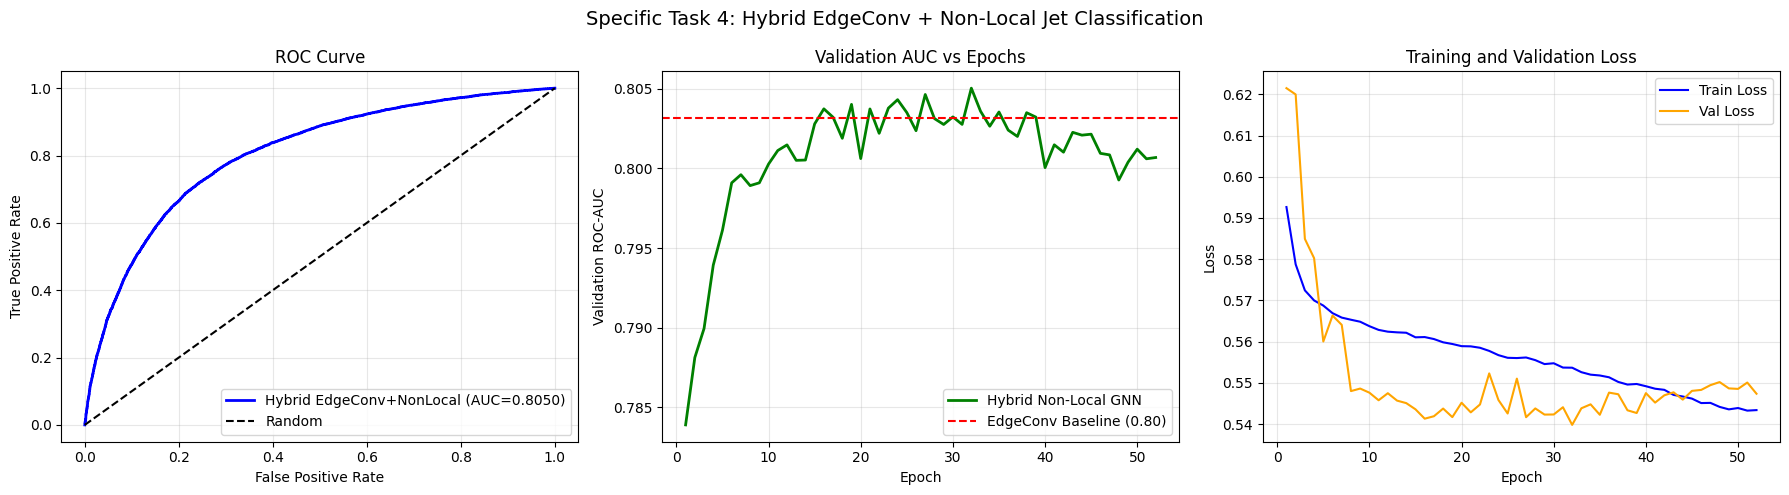

Saved: /kaggle/working/specific_task/models/specific_task4_results.png


In [30]:
# Plots

BASELINE_AUC = 0.8032  # EdgeConv baseline from Common Task 2

fpr, tpr, _ = roc_curve(labels, preds)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='blue', lw=2,
             label=f'Hybrid EdgeConv+NonLocal (AUC={final_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Validation AUC vs epochs
epochs_range = range(1, len(val_aucs) + 1)
axes[1].plot(epochs_range, val_aucs, color='green', lw=2, label='Hybrid Non-Local GNN')
axes[1].axhline(y=BASELINE_AUC, color='red', linestyle='--', lw=1.5,
                label=f'EdgeConv Baseline ({BASELINE_AUC:.2f})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation ROC-AUC')
axes[1].set_title('Validation AUC vs Epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Train vs val loss
axes[2].plot(epochs_range, train_losses, label='Train Loss', color='blue')
axes[2].plot(epochs_range, val_losses, label='Val Loss', color='orange')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].set_title('Training and Validation Loss')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Specific Task 4: Hybrid EdgeConv + Non-Local Jet Classification', fontsize=14)
plt.tight_layout()
plot_path = os.path.join(output_dir, 'specific_task4_results.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {plot_path}")

In [31]:
# Save model and print results

final_model_path = os.path.join(output_dir, 'hybrid_edgeconv_nonlocal.pth')
torch.save(model.state_dict(), final_model_path)
print(f"Saved model: {final_model_path}")

print(f"\nEdgeConv Baseline AUC (Common Task 2): {BASELINE_AUC:.4f}")
print(f"Hybrid EdgeConv + Non-Local GNN AUC:   {final_auc:.4f}")
print(f"Improvement: {final_auc - BASELINE_AUC:+.4f}")

Saved model: /kaggle/working/specific_task/models/hybrid_edgeconv_nonlocal.pth

EdgeConv Baseline AUC (Common Task 2): 0.8032
Hybrid EdgeConv + Non-Local GNN AUC:   0.8050
Improvement: +0.0018
